In [2]:
import sys
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Audio, display


def find_project_root(start_path: Path) -> Path:
    """Find the project folder containing src/config.py."""
    current_path = start_path.resolve()

    for candidate in [current_path, *current_path.parents]:
        if (candidate / "src" / "config.py").exists():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Open the notebook from the "
        "music-genre-classification-AI project folder."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    GENRES,
    RAW_DATA_DIR,
    SAMPLE_RATE,
    DURATION,
    N_FFT,
    HOP_LENGTH,
)

AUDIO_DIR = Path(RAW_DATA_DIR) / "genres_original"

print("Python executable:", sys.executable)
print("Librosa version:", librosa.__version__)
print("Project root:", PROJECT_ROOT)
print("Audio directory:", AUDIO_DIR)
print("Dataset exists:", AUDIO_DIR.exists())
print("Genres:", GENRES)

if ".venv" not in sys.executable:
    raise RuntimeError(
        "Wrong notebook kernel selected. Select the project's .venv kernel."
    )

if not AUDIO_DIR.exists():
    raise FileNotFoundError(
        f"Dataset folder was not found:\n{AUDIO_DIR}\n\n"
        "Required location:\n"
        "data/raw/genres_original/"
    )

Python executable: d:\Projects\music-genre-classification-AI\.venv\Scripts\python.exe
Librosa version: 0.11.0
Project root: D:\Projects\music-genre-classification-AI
Audio directory: D:\Projects\music-genre-classification-AI\data\raw\genres_original
Dataset exists: True
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [3]:
genre_records = []

for genre in GENRES:
    genre_directory = AUDIO_DIR / genre

    if genre_directory.is_dir():
        audio_files = sorted(
            genre_directory.glob("*.wav")
        )
    else:
        audio_files = []

    genre_records.append(
        {
            "genre": genre,
            "folder_exists": genre_directory.is_dir(),
            "file_count": len(audio_files),
        }
    )

genre_summary_df = pd.DataFrame(genre_records)

display(genre_summary_df)

print(
    "Total genres:",
    genre_summary_df["folder_exists"].sum(),
)

print(
    "Total WAV files:",
    genre_summary_df["file_count"].sum(),
)

,genre,folder_exists,file_count
0,blues,True,100
1,classical,True,100
2,country,True,100
3,disco,True,100
4,hiphop,True,100
5,jazz,True,100
6,metal,True,100
7,pop,True,100
8,reggae,True,100
9,rock,True,100


Total genres: 10
Total WAV files: 1000


In [4]:
SELECTED_GENRE = "blues"

if SELECTED_GENRE not in GENRES:
    raise ValueError(
        f"Unknown genre: {SELECTED_GENRE}"
    )

selected_genre_directory = AUDIO_DIR / SELECTED_GENRE

example_files = sorted(
    selected_genre_directory.glob("*.wav")
)

if not example_files:
    raise FileNotFoundError(
        f"No WAV files found in {selected_genre_directory}"
    )

example_path = example_files[0]

print("Selected genre:", SELECTED_GENRE)
print("Selected file:", example_path.name)
print("Full path:", example_path)

Selected genre: blues
Selected file: blues.00000.wav
Full path: D:\Projects\music-genre-classification-AI\data\raw\genres_original\blues\blues.00000.wav


In [5]:
signal, sample_rate = librosa.load(
    example_path,
    sr=SAMPLE_RATE,
    mono=True,
)

audio_duration = librosa.get_duration(
    y=signal,
    sr=sample_rate,
)

print("Filename:", example_path.name)
print("Genre:", SELECTED_GENRE)
print("Sample rate:", sample_rate)
print("Number of samples:", len(signal))
print(f"Duration: {audio_duration:.2f} seconds")
print(f"Minimum amplitude: {signal.min():.4f}")
print(f"Maximum amplitude: {signal.max():.4f}")

display(
    Audio(
        data=signal,
        rate=sample_rate,
    )
)

Filename: blues.00000.wav
Genre: blues
Sample rate: 22050
Number of samples: 661794
Duration: 30.01 seconds
Minimum amplitude: -0.8402
Maximum amplitude: 0.8854


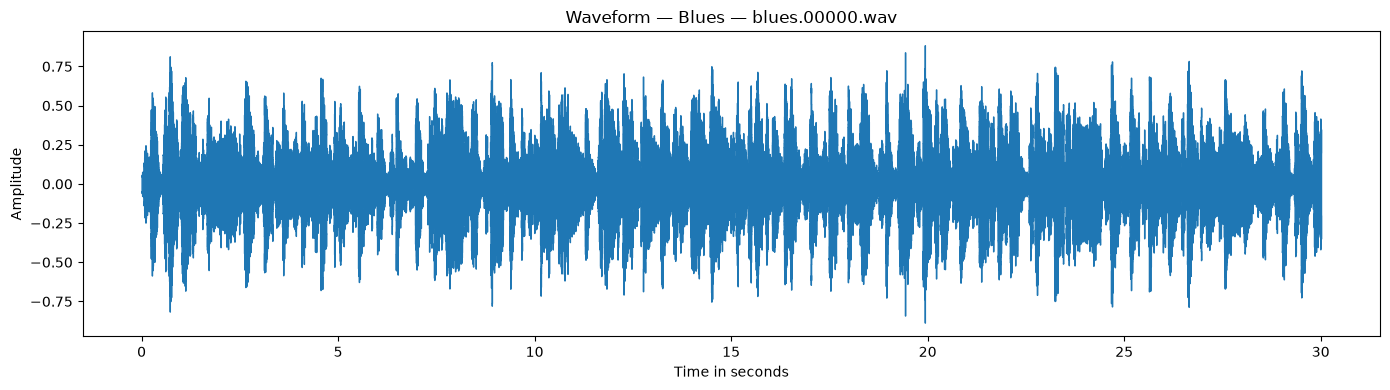

In [6]:
plt.figure(figsize=(14, 4))

librosa.display.waveshow(
    signal,
    sr=sample_rate,
)

plt.title(
    f"Waveform — {SELECTED_GENRE.title()} — "
    f"{example_path.name}"
)

plt.xlabel("Time in seconds")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

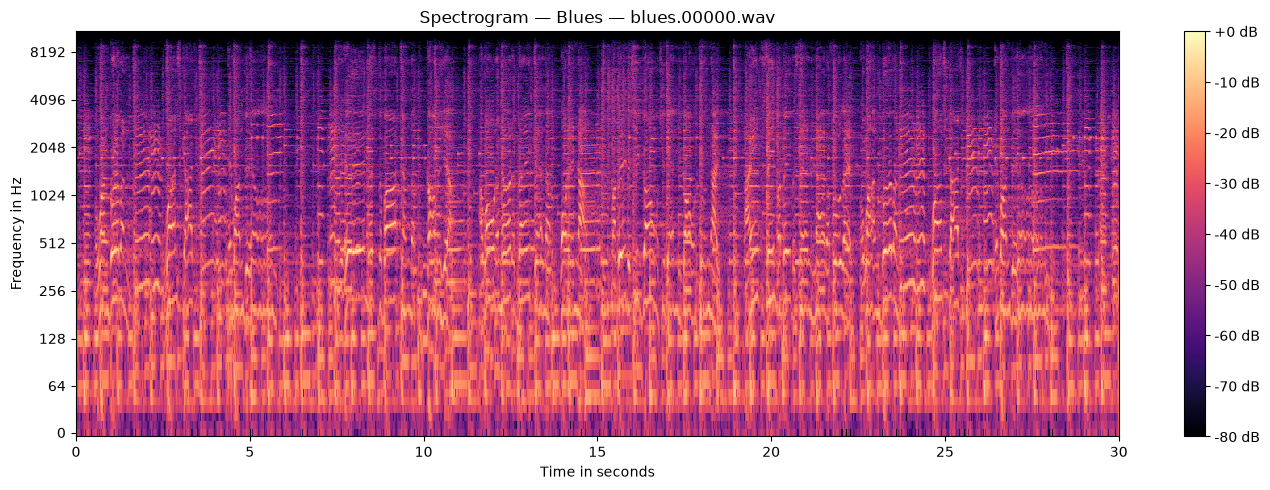

In [7]:
stft_matrix = librosa.stft(
    y=signal,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
)

stft_amplitude = np.abs(stft_matrix)

stft_db = librosa.amplitude_to_db(
    stft_amplitude,
    ref=np.max,
)

plt.figure(figsize=(14, 5))

librosa.display.specshow(
    stft_db,
    sr=sample_rate,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="log",
)

plt.colorbar(format="%+2.0f dB")

plt.title(
    f"Spectrogram — {SELECTED_GENRE.title()} — "
    f"{example_path.name}"
)

plt.xlabel("Time in seconds")
plt.ylabel("Frequency in Hz")
plt.tight_layout()
plt.show()

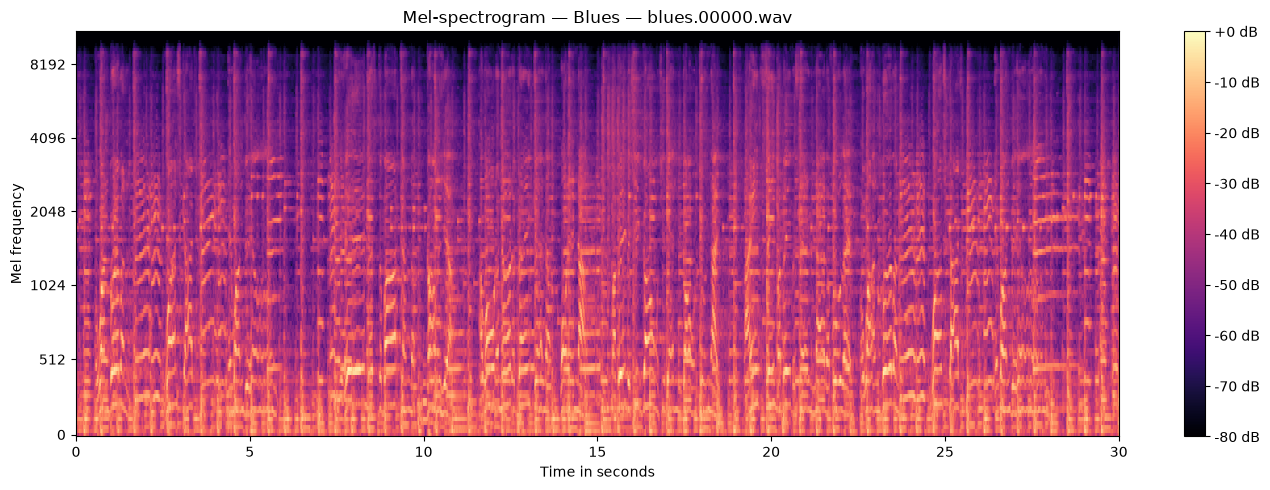

In [8]:
mel_spectrogram = librosa.feature.melspectrogram(
    y=signal,
    sr=sample_rate,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=128,
)

mel_db = librosa.power_to_db(
    mel_spectrogram,
    ref=np.max,
)

plt.figure(figsize=(14, 5))

librosa.display.specshow(
    mel_db,
    sr=sample_rate,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
)

plt.colorbar(format="%+2.0f dB")

plt.title(
    f"Mel-spectrogram — {SELECTED_GENRE.title()} — "
    f"{example_path.name}"
)

plt.xlabel("Time in seconds")
plt.ylabel("Mel frequency")
plt.tight_layout()
plt.show()

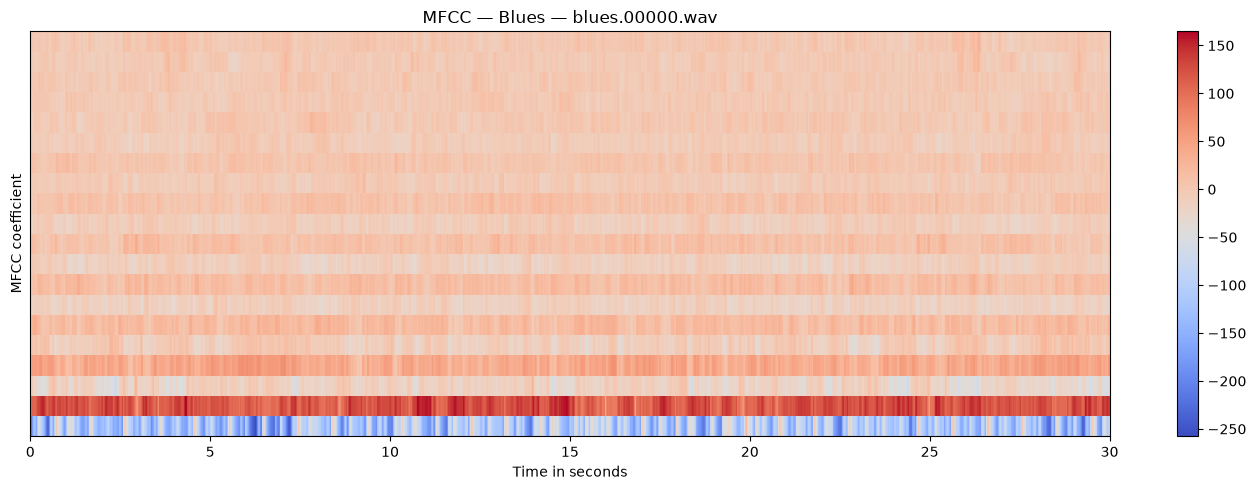

In [9]:
mfcc = librosa.feature.mfcc(
    y=signal,
    sr=sample_rate,
    n_mfcc=20,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
)

plt.figure(figsize=(14, 5))

librosa.display.specshow(
    mfcc,
    sr=sample_rate,
    hop_length=HOP_LENGTH,
    x_axis="time",
)

plt.colorbar()

plt.title(
    f"MFCC — {SELECTED_GENRE.title()} — "
    f"{example_path.name}"
)

plt.xlabel("Time in seconds")
plt.ylabel("MFCC coefficient")
plt.tight_layout()
plt.show()

In [10]:
rms = librosa.feature.rms(
    y=signal,
    frame_length=N_FFT,
    hop_length=HOP_LENGTH,
)

zero_crossing_rate = librosa.feature.zero_crossing_rate(
    y=signal,
    frame_length=N_FFT,
    hop_length=HOP_LENGTH,
)

spectral_centroid = librosa.feature.spectral_centroid(
    y=signal,
    sr=sample_rate,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
)

spectral_bandwidth = librosa.feature.spectral_bandwidth(
    y=signal,
    sr=sample_rate,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
)

spectral_rolloff = librosa.feature.spectral_rolloff(
    y=signal,
    sr=sample_rate,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
)

tempo_values = librosa.feature.tempo(
    y=signal,
    sr=sample_rate,
    hop_length=HOP_LENGTH,
)

feature_summary = {
    "genre": SELECTED_GENRE,
    "filename": example_path.name,
    "duration_seconds": audio_duration,
    "sample_rate": sample_rate,
    "rms_mean": float(np.mean(rms)),
    "zero_crossing_rate_mean": float(
        np.mean(zero_crossing_rate)
    ),
    "spectral_centroid_mean": float(
        np.mean(spectral_centroid)
    ),
    "spectral_bandwidth_mean": float(
        np.mean(spectral_bandwidth)
    ),
    "spectral_rolloff_mean": float(
        np.mean(spectral_rolloff)
    ),
    "tempo_bpm": float(tempo_values[0]),
}

for index in range(min(5, mfcc.shape[0])):
    feature_summary[f"mfcc_{index + 1}_mean"] = float(
        np.mean(mfcc[index])
    )

feature_summary_df = pd.DataFrame(
    [feature_summary]
)

display(feature_summary_df.T)

,0
genre,blues
filename,blues.00000.wav
duration_seconds,30.013333
sample_rate,22050
rms_mean,0.130184
zero_crossing_rate_mean,0.083045
spectral_centroid_mean,1784.122641
spectral_bandwidth_mean,2002.412407
spectral_rolloff_mean,3805.72303
tempo_bpm,123.046875
